In [63]:
# Standard data libs
import os
import pandas as pd
import numpy as np

# Plotting (optional but useful for diagnostics)
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
# Preprocessing & pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model, search, and metrics
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [65]:
# Save model
from joblib import dump

Load data & quick peek

In [66]:
TRAIN_PATH = "train_df.csv"
TEST_PATH = "test_df.csv"

In [67]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

target = "salary_in_usd"

In [68]:
print("Train shape:", train.shape)
print("Test  shape:", test.shape)

Train shape: (41929, 9)
Test  shape: (10483, 9)


Split X / y

In [69]:
X_train = train.drop(columns=[target])
y_train = train[target]

X_test = test.drop(columns=[target])
y_test = test[target]


In [70]:
print("X_train columns:", X_train.columns.tolist())
print("y_train size:", y_train.shape)

X_train columns: ['work_year', 'experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']
y_train size: (41929,)


Frequency encoding for high-cardinality categories

In [71]:
freq_cols = ["job_title", "employee_residence", "company_location"]

In [72]:
def frequency_encode(train_series, test_series):
    freq = train_series.value_counts() / len(train_series)
    train_enc = train_series.map(freq)           
    test_enc = test_series.map(freq).fillna(0.0)  
    return train_enc, test_enc

In [73]:
for col in freq_cols:
    X_train[col], X_test[col] = frequency_encode(X_train[col], X_test[col])

In [74]:
display(X_train[freq_cols].head())

,job_title,employee_residence,company_location
0,0.003339,0.844881,0.845882
1,0.008824,0.844881,0.845882
2,0.017983,0.844881,0.845882
3,0.059577,0.844881,0.845882
4,0.059577,0.844881,0.845882


ColumnTransformer (OneHot for small cats, scale numeric)

In [75]:
# Small cardinality categorical columns to one-hot encode
onehot_cols = ["experience_level", "employment_type", "company_size"]

In [76]:
# Numeric columns now include original numeric features plus the frequency-encoded columns
numeric_cols = ["work_year", "remote_ratio"] + freq_cols


In [77]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [78]:


preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown='ignore'), onehot_cols),
        ("scale", StandardScaler(), numeric_cols)
    ],
    remainder="drop"
)

In [79]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('onehot',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['experience_level', 'employment_type',
                                  'company_size']),
                                ('scale', StandardScaler(),
                                 ['work_year', 'remote_ratio', 'job_title',
                                  'employee_residence', 'company_location'])])

Inspect transformed feature shape & sample

In [80]:
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans  = preprocessor.transform(X_test)

print("Transformed train shape:", X_train_trans.shape)
print("Transformed test  shape:", X_test_trans.shape)


Transformed train shape: (41929, 16)
Transformed test  shape: (10483, 16)


In [81]:
ohe_cols = []
ohe_transformer = preprocessor.named_transformers_["onehot"]
if hasattr(ohe_transformer, "get_feature_names_out"):
    ohe_cols = list(ohe_transformer.get_feature_names_out(onehot_cols))
else:
    # fallback (older sklearn): build manually from categories_
    for i, col in enumerate(onehot_cols):
        cats = preprocessor.named_transformers_["onehot"].categories_[i]
        ohe_cols.extend([f"{col}_{c}" for c in cats])

final_cols = ohe_cols + numeric_cols

In [82]:
X_train_df = pd.DataFrame(X_train_trans, columns=final_cols)
display(X_train_df.head())

,experience_level_EN,experience_level_EX,experience_level_MI,experience_level_SE,employment_type_CT,employment_type_FL,employment_type_FT,employment_type_PT,company_size_L,company_size_M,company_size_S,work_year,remote_ratio,job_title,employee_residence,company_location
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.28994,-0.577189,-1.143332,0.428265,0.426629
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.06898,1.746028,-1.012418,0.428265,0.426629
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.06898,-0.577189,-0.793850,0.428265,0.426629
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.28994,-0.577189,0.198813,0.428265,0.426629
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.06898,-0.577189,0.198813,0.428265,0.426629


Build KNN pipeline (preprocessor + knn)

In [83]:
pipeline = Pipeline([
    ("preprocess", preprocessor),                       # column transformations
    ("knn", KNeighborsRegressor())                      # KNN placeholder (we'll tune params)
])

Baseline KNN fit (K=5)

In [84]:
baseline = Pipeline([
    ("preprocess", preprocessor),
    ("knn", KNeighborsRegressor(n_neighbors=5, weights="uniform", p=2))  # p=2 -> Euclidean
])

In [85]:
# TRAIN MODEL
baseline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['experience_level',
                                                   'employment_type',
                                                   'company_size']),
                                                 ('scale', StandardScaler(),
                                                  ['work_year', 'remote_ratio',
                                                   'job_title',
                                                   'employee_residence',
                                                   'company_location'])])),
                ('knn', KNeighborsRegressor())])

In [86]:
# PREDICT
y_pred_baseline = baseline.predict(X_test)

In [87]:

# EVALUATE
mae = mean_absolute_error(y_test, y_pred_baseline)
mse = mean_squared_error(y_test, y_pred_baseline)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_baseline)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 51598.751178097875
MSE: 5091506183.260124
RMSE: 71354.79089213368
R²: 0.16758778803245045


Hyperparameter tuning (GridSearchCV for K, weights, metric p)

In [88]:
# Cell 9 — Grid search for best K (and weights/p)
param_grid = {
    "knn__n_neighbors": list(range(1, 31, 2)),   # odd values 1..29
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]                             # p=1 Manhattan, p=2 Euclidean
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)



In [89]:
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV MSE:", -grid.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'knn__n_neighbors': 25, 'knn__p': 1, 'knn__weights': 'uniform'}
Best CV MSE: 4645185131.048277


Plot K vs CV MSE

In [90]:
# Cell 10 — Plot K vs CV MSE (averaged over other params)
cv_results = pd.DataFrame(grid.cv_results_)
cv_results["mean_test_mse"] = -cv_results["mean_test_score"]

# average over other params to plot effect of n_neighbors
grouped = cv_results.groupby("param_knn__n_neighbors")["mean_test_mse"].mean()



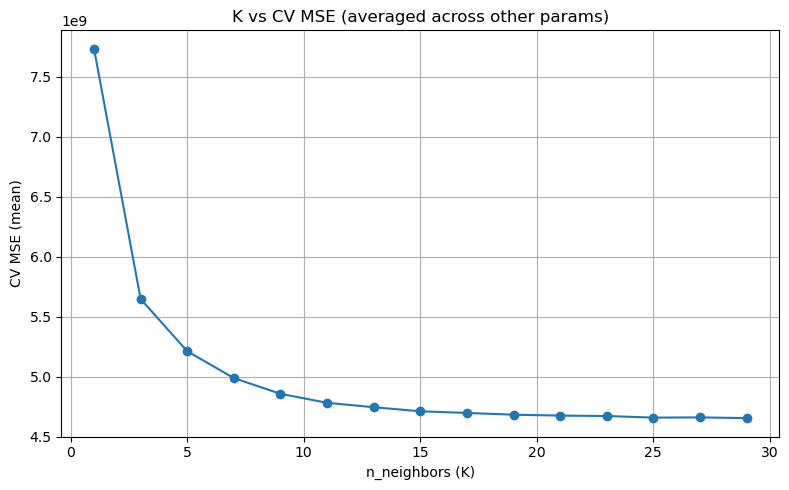

In [91]:
plt.figure(figsize=(8,5))
plt.plot(grouped.index.astype(int), grouped.values, marker="o")
plt.xlabel("n_neighbors (K)")
plt.ylabel("CV MSE (mean)")
plt.title("K vs CV MSE (averaged across other params)")
plt.grid(True)
plt.tight_layout()
plt.show()


Evaluate the best model on the test set

In [92]:
best_model = grid.best_estimator_   # pipeline with best hyperparameters
y_pred = best_model.predict(X_test)

In [93]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Test set performance (best model):")
print(f"MAE:  {mae:.3f}")
print(f"MSE:  {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2:   {r2:.3f}")


Test set performance (best model):
MAE:  49258.847
MSE:  4628094869.531
RMSE: 68030.103
R2:   0.243


Actual vs Predicted plot

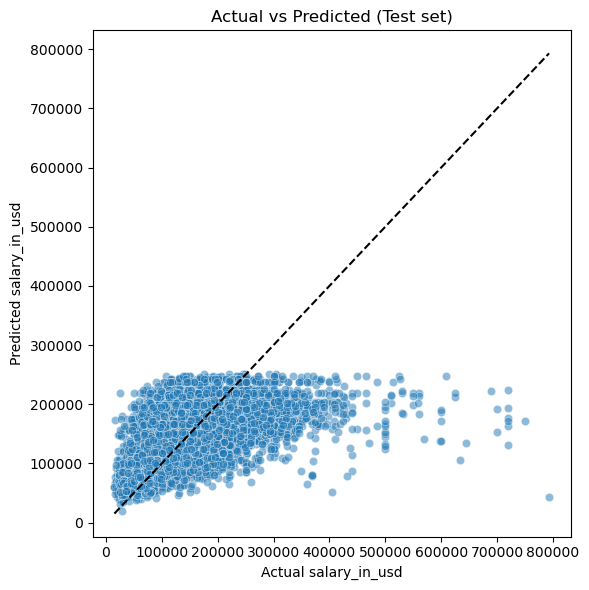

In [94]:
# Cell 12 — Visual: Actual vs Predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
minv = min(y_test.min(), y_pred.min())
maxv = max(y_test.max(), y_pred.max())
plt.plot([minv, maxv], [minv, maxv], linestyle="--", color="black")
plt.xlabel("Actual salary_in_usd")
plt.ylabel("Predicted salary_in_usd")
plt.title("Actual vs Predicted (Test set)")
plt.tight_layout()
plt.show()


Save best pipeline & preprocessed features

In [98]:
# Cell 13 — Save the best pipeline and preprocessor (joblib)
os.makedirs("models", exist_ok=True)
dump(best_model, "models/knn_best_model.joblib")
print("Saved best pipeline to models/knn_best_model.joblib")


Saved best pipeline to models/knn_best_model.joblib
